<h1 style="font-size: 36px; color: blue;">STOWA Proevenverzameling tool v5.0</h1>

Deze Jupyter notebook bevat functies opgenomen in de python package PV-tooling ### voor het opstellen van lokale of regionale proevenverzamelingen voor het bepalen van geotechnische parameters. De methode is ontwikkeld voor het uitvoeren van analyses in relatie tot de geotechnische stabiliteit van dijken, maar kan ook breder worden toegepast. De notebook dient tevens als handleiding om de gebruiker stapsgewijs te ondersteunen bij het opstellen van een proevenverzameling.

Met de beschikbare functies kunnen zowel gedraineerde als ongedraineerde sterkteparameters worden berekend alsmede enkele samendrukkingsparameters. Van deze parameters worden verwachtingswaarde, karakteristieke waarde en rekenwaarde bepaald. 

De functies zijn opgesteld conform de werkwijze beschreven in [Statistische methoden t.b.v. proevenverzamelingen, DIV, v1.0], zie tevens: https://publicwiki.deltares.nl/spaces/HWBPMacro/pages/217120830/Sterkte+van+grond#Sterktevangrond-150.
De tool bevat tevens hulpmiddelen voor het onderscheiden of samenvoegen van groepen in een verzameling op basis van verschillende kenmerken. 

De onderliggende data om een proevenverzameling samen te stellen is beschreven in een vaste structuur. Deze structuur is vastgelegd in een uitwisselformat. Het uitwisselformat-database-proevenverzameling_versie_4_2x.xlsx. De geotechnische laboratoria kennen deze database en kunnen deze database vullen met resultaten van grond- en laboratoriumonderzoek. Op deze wijze ontstaat er uniformering op het gebied van data-uitwisseling en –opslag van proefresultaten.

NB. De verantwoordelijkheid voor het gebruik van deze tools ligt bij de gebruiker.

In [2]:
# Importeren van benodigde packages
# Na het eerte keer installeren van de benodigde packages de kernel handmatig opnieuw optarten via het menu Kernel → Restart

import importlib.util

# Functie om te controleren of een package is geïnstalleerd
def check_package_install(package_name):
    package_spec = importlib.util.find_spec(package_name)
    if package_spec is None:
        print(f"{package_name} is niet geïnstalleerd. Installatie wordt gestart...")
        !pip install {package_name}
    else:
        print(f"{package_name} is al geïnstalleerd.")

# Controleer en installeer indien nodig
check_package_install("openpyxl")
check_package_install("ipyfilechooser")
check_package_install("pandas_schema")
check_package_install("xlsxwriter")
check_package_install("ipywidgets")
check_package_install("reportlab")
check_package_install("kaleido")

#!pip uninstall C:\python_cursus\PVtool2025_github\dist\pv_tool-0.1.0-py3-none-any.whl
#!pip install --force-reinstall C:\python_cursus\PVtool2025_github\dist\pv_tool-0.1.3-py3-none-any.whl

#!pip install C:\python_cursus\PVtool2025_github\dist\pv_tool-0.2.0-py3-none-any.whl


openpyxl is al geïnstalleerd.
ipyfilechooser is al geïnstalleerd.
pandas_schema is al geïnstalleerd.
xlsxwriter is al geïnstalleerd.
ipywidgets is al geïnstalleerd.
reportlab is al geïnstalleerd.
kaleido is al geïnstalleerd.


## Stap 1: Inladen van benodigde data

De benodigde data voor het bepalen van geotechnische parameters kan op 3 manieren worden ingeladen in deze notebook.
- Op basis van de data in de excel versie van de proevenverzamelingtool (vanaf versie 4.2n of hoger) waarin zowel reeds proevenverzamelingen zijn onderscheiden als geotechnische parameters zijn vastgesteld. NB. de onderscheiden verzamelingen worden als uitgangspunt worden ingeladen, de sterkteparameters worden opnieuw berekend. Onderliggende keuzes zoals het gewenste rekpercentage en de gekozen raaklijnen worden niet ingelezen uit de Excelversie. 
- Op basis van het Excel Uitwisselformat-database-proevenverzameling_versie_4_2x.xlsx waarin nog geen verzamelingen onderscheiden zijn.

Zie tevens: https://github.com/kkpdata/Proevenverzamelingentool/

De proevenverzamelingtool of het uitwisselformat worden omgezet naar het template proevenverzamelingtool 5.0 

- Op basis van het Excel template voor de Proevenverzameling 5.0. Deze bestaat uit de data conform het uitwisselformat 4.2 aangevuld met de benodigde in en uitvoerdata van voorliggende tooling.

In [1]:
# Laden van widgets voor uploaden bestanden
import ipywidgets as widgets
from IPython.display import display, Markdown
from ipyfilechooser import FileChooser

# Dropdown widget voor keuze template
dropdown_template = widgets.Dropdown(
    options=[
        'Proevenverzamelingtool 4.2n of hoger', 
        'STOWA uitwisselingsformat 4.2x', 
        'Proevenverzamelingtool 5.0'
    ],  # De opties in het menu
    value='Proevenverzamelingtool 5.0',  # Standaard geselecteerde waarde
    description='Template:',
    disabled=False, 
    layout=widgets.Layout(width='400px') 
)

# Maak een FileChooser-widget
file_chooser_import = FileChooser(
    '/',
    title="Selecteer een bestand om te uploaden",
    show_hidden=False  # Verberg verborgen bestanden
)

#Titel
display(Markdown("**Stap 1: Kies Excel template voor uploaden data:**"))

# Toon de dropdown widget keuze template
display(dropdown_template)

# Toon widget voor keuze uploaden bestand
display(file_chooser_import)

print()

**Stap 1: Kies Excel template voor uploaden data:**

Dropdown(description='Template:', index=2, layout=Layout(width='400px'), options=('Proevenverzamelingtool 4.2n…

FileChooser(path='C:\', filename='', title='Selecteer een bestand om te uploaden', show_hidden=False, select_d…

## Stap 2a: Importeren inclusief toevoegen/herberekenen analyse kolommen
De importfunctie laadt de data in. Daarnaast worden analyse kolommen (ANA) toegevoegd die benodigd zijn voor de functies in "shansep_analysis" en "sutabel_analysis". 

Hiervoor worden verschillende kolommen aangemaakt: 
ANA_TERREINSPANNING, ANA_TXT_MAX_VERTICALE_CONSOLIDATIE_SPANNING, ANA_DSS_MAX_CONSOLIDATIE_SPANNING, ANA_TXT_CONSOLIDATIE_TYPE_VOORSTEL, ANA_TXT_CONSOLIDATIE_TYPE_HANDMATIG, ANA_TXT_CONSOLIDATIE_TYPE_REKEN, ANA_DSS_CONSOLIDATIE_TYPE_VOORSTEL, ANA_DSS_CONSOLIDATIE_TYPE_HANDMATIG
ANA_DSS_CONSOLIDATIE_TYPE_REKEN, ANA_GRENSSPANNING_PROEF, ANA_POP_VELD, ANA_POP_VELD_GEMIDDELD, ANA_GRENSSPANNING_VOORSTEL, ANA_GRENSSPANNING_HANDMATIG
ANA_GRENSSPANNING_REKEN, OCR_TXT, OCR_DSS.

Er moet worden vastgesteld of een proef is uitgevoerd op een normaal geconsolideerd monster (NC) ruim boven de grensspanning of overconsolideerd (OC) bij de geschatte dagelijkse effectieve terreinspanning (OCR>1). De tooling doet hier een voorstel voor door de consolidatiespanning (sigma'vc) te vergelijken met de terreinspanning (sigma'vi). Indien deze niet meer dan +30% afwijkt wordt aangenomen dat het een OC-proef betreft en bij grotere afwijkingen een NC-proef. Het is noodzakelijk om dit voorstel te controleren. In de regel is een OC-proef vrijwel altijd dicht bij de terreinspanning gekozen en ligt een NC-proef er ruim boven, maar hier zijn altijd uitzonderingen op mogelijk.

Daarnaast is een schatting van de OCR benodigd. Om deze te berekenen is een schatting van de grensspanning benodigd. Indien er op dezelfde regel een resultaat beschikbaar is uit een samendrukkingsproef of CRS-proef wordt deze gebruikt. Indien deze ontbreekt wordt een voorstel gedaan op basis van de gemiddelde POP (POP = grensspanning - effectieve terreinspanning o.b.v. de monsters waar wel een proef is uitgevoerd ) per boring. Indien er bij de betreffende boring geen grensspanning beschikbaar is wordt geen waarde ingevuld. Het is dan niet mogelijk om geautomatiseerd een OCR te schatten. 
De data wordt weggeschreven in de velden (ANA_GRENSSPANNING_VOORSTEL). Het is noodzakelijk om de voorgestelde waarden te controleren. Als gebruiker kan je het voorstel overrulen in de kolom (ANA_GRENSSPANNING_HANDMATIG).

NB. Bij gebruik van de bestaande Excel versie van de proevenverzamelingtool zijn de cellen ANA_GRENSSPANNING_HANDMATIG veelal reeds ingevuld. In dat geval worden deze waarden overgenomen.


## Stap 2a: Valideren data 
De validatie bestaat uit de volgende controles: voor de verschillende typen proeven – classificatie, CRS-proef, samendrukkingsproef, DSS-proef en triaxiaalproef – wordt per regel gecontroleerd of er een proef is uitgevoerd (data ingevuld) en zo ja, of de velden die in de PV-tool benodigd zijn volledig en correct zijn ingevuld.

Het resultaat van de validatie wordt opgeslagen in een twee Excel-bestanden Validation_log_##_critical_errors.xlsx en Validation_log_##_warnings.xlsx, waarin per gevalideerde kolom en regel het resultaat wordt weergegeven. Ir is per kolom aangegeven hoeveel fouten zijn aangetroffen. Er is onderscheid gemaakt tussen 'critical errors' en 'warnings'. De critical errors leiden tot fouten wanneer deze data wordt gebruikt bij het bepalen van de parameters. Deze dienen te worden gecorrigeerd of aangevuld. De warnings betreffen aanbevelingen. De resultaten worden weggeschreven in dezelfde directory als de importmap. 

Indien de validatie goed is doorlopen worden proevenverzamelingtool (vanaf versie 4.2n of hoger) of Uitwisselformat-database-proevenverzameling_versie_4_2x.xlsx weggeschreven naar het Template_PVtool5_0.xlsx. Indien reeds gebruik is gemaakt van het nieuwe template worden de analyse kolommen opnieuw berekend. Dit is noodzakelijk indien er data gewijzigd is. 

Indien er reeds een gevalideerde dataset beschikbaar is conform het Template_PVtool5_0 laadt de data dan in via stap 2b. Dit kost aanzienlijk minder rekentijd bij een grote dataset.

In [2]:
from pv_tool.imports.import_data import Dbase
from pathlib import Path
dbase = Dbase()

# Controleer dropdown template en geef de gekozen waarde terug
if dropdown_template.value:
    print(f'Je hebt gekozen: {dropdown_template.value}')
else:
    print("Er is geen template geselecteerd.")

# bepaal source voor template
template_mapping = {
    "Proevenverzamelingtool 4.2n of hoger" : "PV-tool",
    "STOWA uitwisselingsformat 4.2x" : "Stowa",
    "Proevenverzamelingtool 5.0" : "Dbase"
}
template_code = template_mapping.get(dropdown_template.value, "Onbekend template")
print(f"Code in script: {template_code}")

# Controleer of een bestand is geselecteerd
if file_chooser_import.selected:
    # Verkrijg het volledige pad van het geselecteerde bestand
    full_path = file_chooser_import.selected
    # Verkrijg de directory en bestandsnaam
    selected_directory = file_chooser_import.selected_path
    filename = file_chooser_import.selected_filename

    # Print de resultaten
    print(f"Geselecteerd bestand: {filename}")
    print(f"Geselecteerde directory: {selected_directory}")
    print(f"Volledig pad: {full_path}")
else:
    print("Er is geen bestand geselecteerd. Selecteer een bestand voordat je verder gaat.")

#import dir en bestandsnaam en export directory
dir_in = (file_chooser_import.selected)
dir2 = Path(file_chooser_import.selected_path)

#starten importeren 
dbase.import_data(source = template_code, source_dir=dir_in)

#starten validatie 
dbase.validate_data(export_path=dir2)

# Bepaal bestandsnaam voor de export van de data, bij PV4.2 of 4.2 uitwisselformat standaard export naar Template_PVtool5_0.xlsx
if dropdown_template.value in ['Proevenverzamelingtool 4.2n of hoger', 'STOWA uitwisselingsformat 4.2x']:
    filename_export = 'Template_PVtool5_0.xlsx'
elif dropdown_template.value == 'Proevenverzamelingtool 5.0':
    filename_export = file_chooser_import.selected_filename

#Export naar Template_PVtool5_0.xlsx 
dbase.export_dbase_to_excel(export_dir=dir2, filename=filename_export)

Je hebt gekozen: Proevenverzamelingtool 5.0
Code in script: Dbase
Geselecteerd bestand: WSRL 2025 PVtool5_0_gevalideerd.xlsx
Geselecteerde directory: C:\python_cursus\PVtool2025_github\import
Volledig pad: C:\python_cursus\PVtool2025_github\import\WSRL 2025 PVtool5_0_gevalideerd.xlsx
number of critical_errors in validate_kenmerken_boring = 63
number of critical_errors in validate_clas = 0
number of critical_errors in validate_crs = 3
number of critical_errors in validate_samendrukking = 0
number of critical_errors in validate_monster = 0
number of critical_errors in validate_triaxiaal = 0
number of critical_errors in validate_dss = 0
number of warnings in validate_alg = 922
number of warnings in validate_kenmerken_boring = 643
number of warnings in validate_clas = 2140
number of warnings in validate_crs = 33
number of warnings in validate_samendrukking = 539
number of warnings in validate_monster = 0
number of warnings in validate_triaxiaal = 198
number of warnings in validate_dss = 86

## Stap 2b: Importeren data zonder validatie of herberekening analysekolommen

De importfunctie laadt de data conform het Template_PVtool5_0. Deze functie mag alleen gebruikt worden indien er reeds een gevalideerde dataset beschikbaar is conform het Template_PVtool5_0. Na het aanbrengen van wijzigingen in de data altijd stap 2a toepassen voor het importeren. Dit is noodzakelijk omdat de analsyekolommen benodigd voor onderstaande functies opnieuw berekend moeten worden bij aanpassingen aan de data. 

In [16]:
from pv_tool.imports.import_data import Dbase
from pathlib import Path
dbase = Dbase()

# bepaal source voor template
template_mapping = {
    "Proevenverzamelingtool 4.2n of hoger" : "PV-tool",
    "STOWA uitwisselingsformat 4.2x" : "Stowa",
    "Proevenverzamelingtool 5.0" : "Dbase"
}
template_code = template_mapping.get(dropdown_template.value, "Onbekend template")

# Controleer of het juiste template en bestand is geselecteerd
if template_code != "Dbase":
    print("Deze importfunctie werkt alleen voor Proevenverzamelingtool 5.0. Selecteer het juiste format!")
elif not file_chooser_import.selected:
    print("Er is geen bestand geselecteerd. Selecteer een bestand voordat je verder gaat.")

# Definieer pad, locatie en directory dbase bestand
else:
    full_path = file_chooser_import.selected
    selected_directory = file_chooser_import.selected_path
    filename = file_chooser_import.selected_filename
    print(f"Importeren: {full_path}")
    dir2 = Path(selected_directory)

# Bepaal bestandsnaam voor de export van data, bij PV4.2 of 4.2 uitwisselformat standaard export naar Template_PVtool5_0.xlsx
if dropdown_template.value in ['Proevenverzamelingtool 4.2n of hoger', 'STOWA uitwisselingsformat 4.2x']:
    filename_export = 'Template_PVtool5_0.xlsx'
elif dropdown_template.value == 'Proevenverzamelingtool 5.0':
    filename_export = file_chooser_import.selected_filename

# Start importeren zonder validatie
dbase.import_dbase_short(source=template_code, source_dir=full_path)

Importeren: C:\python_cursus\PVtool2025_github\import\WSRL 2025 PVtool5_0_gevalideerd.xlsx


,ALG__REGEL,ALG__CLASSIFICATIE,ALG__VEENCLASSIFICATIE,ALG__KORRELVERDELING,ALG__SONDEERWAARDE,ALG__CRS,ALG__SAMENDRUKKING,ALG__DSS,ALG__TRIAXIAAL,ALG_OPDRACHTGEVER,...,ANA_DSS_CONSOLIDATIE_TYPE_HANDMATIG,ANA_DSS_CONSOLIDATIE_TYPE_REKEN,ANA_GRENSSPANNING_PROEF,ANA_POP_VELD,ANA_POP_VELD_GEMIDDELD,ANA_GRENSSPANNING_VOORSTEL,ANA_GRENSSPANNING_HANDMATIG,ANA_GRENSSPANNING_REKEN,OCR_TXT,OCR_DSS
ALG__BORING_MONSTERNR_ID,,,,,,,,,,,,,,,,,,,,,
1_B01_1,1,False,NaN,NaN,NaN,True,False,True,False,NaN,...,NaN,OC,42.436417,6.836417,16.761692,NaN,42.000000,42.000000,NaN,1.179775
2_B01_2,2,False,NaN,NaN,NaN,False,False,True,False,NaN,...,NaN,OC,NaN,NaN,16.761692,53.861692,65.000000,65.000000,NaN,1.752022
3_B01_3,3,False,NaN,NaN,NaN,False,False,True,False,NaN,...,NaN,OC,NaN,NaN,16.761692,54.761692,48.000000,48.000000,NaN,1.263158
4_B01_4,4,True,NaN,NaN,NaN,False,True,True,False,NaN,...,NaN,OC,49.160000,11.760000,16.761692,NaN,50.000000,50.000000,NaN,1.336898
5_B02_5,5,True,NaN,NaN,NaN,True,False,True,False,NaN,...,NaN,OC,163.332257,68.990045,67.047717,NaN,125.000000,125.000000,NaN,1.324964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4871__86835_MB1101_(ND034.+089_B_BUK)_M011-a2,4871,True,NaN,NaN,NaN,False,False,False,True,WSRL,...,NaN,NaN,NaN,NaN,58.232114,136.632114,136.632114,136.632114,1.742757,NaN
4872__86835_MB1101_(ND034.+089_B_BUK)_M014-a3,4872,True,NaN,NaN,NaN,False,False,False,True,WSRL,...,NaN,NaN,NaN,NaN,58.232114,158.532114,158.532114,158.532114,1.580579,NaN
4873__86835_MB1101_(ND034.+089_B_BUK)_M014-a1,4873,True,NaN,NaN,NaN,True,False,False,False,WSRL,...,NaN,NaN,178.422267,78.122267,58.232114,NaN,NaN,178.422267,NaN,NaN


## Stap 4a: Bepalen gedraineerde parameters triaxiaalproeven en DSS-proeven op basis van fit (C en Phi)

In deze stap worden op basis van de data vastgelegd in het template PV-tool 5.0. gedraineerde parameters bepaald. Maak  een keuze uit de verzameling waarop de statistische analyse moet plaatsvinden. Als er nog geen aparte verzamelingen onderscheiden zijn in het veld (PV_NAAM) worden alle triaxaalproeven in één verzameling opgenomen. 

Als gebruiker kunnen handmatig verzamelingen worden opgegeven in de Excel template in het veld PV_NAAM of er kan gebruik worden gemaakt van de functie:
Definiëren en aanpassen van verzamelingen (stap #). Met behulp van de functie ## kunnen in de grafiek met behulp van de selectietool (should have) ook één of meer proefresultaten worden geselecteerd en worden toegekend aan een andere groep.

Geef  het te hanteren rekpercentage op waarbij de s' en t zijn bepaald: 2%, 5%, 15%, eindrek of bij pieksterkte. 
Indien er eerder parameters zijn vastgesteld worden de gemaakte keuzes voor het % en de raaklijnen ingeladen.

Ook kunnen meerdere verzamelingen getoond worden. NB. Deze extra verzamelingen worden niet meegenomen in de statistische analyse.

In [3]:
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output

# Dataframe met proefdata
dbase_df = dbase.dbase_df

# Lijsten maken met proevenverzamelingen in database onder PVNAAM
PV_txt_lijst = ['geen'] + dbase_df.loc[dbase_df['ALG__TRIAXIAAL'], 'PV_NAAM'].dropna().unique().tolist()
PV_dss_lijst = ['geen'] + dbase_df.loc[dbase_df['ALG__DSS'], 'PV_NAAM'].dropna().unique().tolist()
gekozen_rekpercentage = 'eindsterkte'

# Dropdown widgets
dropdown_type_proef = widgets.Dropdown(options=['TXT_CPhi', 'DSS_CPhi'], value='TXT_CPhi', layout=widgets.Layout(width='400px'))
dropdown_rekpercentage_txt = widgets.Dropdown(options=['2% rek', '5% rek', '15% rek', 'eindsterkte', 'pieksterkte'], value='eindsterkte', layout=widgets.Layout(width='400px'))
dropdown_rekpercentage_dss = widgets.Dropdown(options=['2% rek', '5% rek', '10% rek', '15% rek', '20% rek', 'eindsterkte', 'pieksterkte'], value='eindsterkte', layout=widgets.Layout(width='400px'))
dropdown_verzameling = widgets.Dropdown(options=PV_txt_lijst, value=PV_txt_lijst[0] if PV_txt_lijst else None, layout=widgets.Layout(width='400px'))
multi_select_verzameling = widgets.SelectMultiple(options=PV_txt_lijst, value=[PV_txt_lijst[0]] if PV_txt_lijst else [], layout=widgets.Layout(width='400px', height='150px'))

# Outputs
container_rekpercentage = widgets.Output()
output_rekpercentage = widgets.Output()

# Lijsten rekpercentage en  verzamelingen aanpassen bij wijziging van proeftype txt/dss
def update_verzamelings_dropdowns(change): 
    with container_rekpercentage: 
        clear_output(); 
        (dropdown_verzameling.options, dropdown_verzameling.value, multi_select_verzameling.options, multi_select_verzameling.value, _d) = \
            (PV_txt_lijst, PV_txt_lijst[0], PV_txt_lijst, [PV_txt_lijst[0]], display(dropdown_rekpercentage_txt)) if dropdown_type_proef.value == 'TXT_CPhi' \
            else (PV_dss_lijst, PV_dss_lijst[0], PV_dss_lijst, [PV_dss_lijst[0]], display(dropdown_rekpercentage_dss))
    update_rekpercentage_output(None)

def update_rekpercentage_output(change):
    global gekozen_rekpercentage
    with output_rekpercentage:
        clear_output()
        if dropdown_type_proef.value == 'TXT_CPhi':
            gekozen_rekpercentage = dropdown_rekpercentage_txt.value
        else:
            gekozen_rekpercentage = dropdown_rekpercentage_dss.value

dropdown_type_proef.observe(update_verzamelings_dropdowns, names='value')
dropdown_rekpercentage_txt.observe(update_rekpercentage_output, names='value')
dropdown_rekpercentage_dss.observe(update_rekpercentage_output, names='value')

# Initialiseren container met juiste rekpercentage-dropdown
with container_rekpercentage:
    clear_output()
    display(dropdown_rekpercentage_txt)
with output_rekpercentage:
    clear_output()

# Display widgets
display(Markdown("**Kies type proef:**"))
display(dropdown_type_proef)
display(Markdown("**Kies verzameling voor statistische analyse:**"))
display(dropdown_verzameling)
display(Markdown("**Kies rekpercentage s'en t:**"))
display(container_rekpercentage)
display(output_rekpercentage)
display(Markdown("**Kies één of meerdere verzamelingen om naast de gekozen verzameling voor de statistische analyse te tonen:**"))
display(multi_select_verzameling)

**Kies type proef:**

Dropdown(layout=Layout(width='400px'), options=('TXT_CPhi', 'DSS_CPhi'), value='TXT_CPhi')

**Kies verzameling voor statistische analyse:**

Dropdown(layout=Layout(width='400px'), options=('geen', 'TXT_testset_klei', 'TXT', 'TXT_klei_17.5_21_ondiep', …

**Kies rekpercentage s'en t:**

Output()

Output()

**Kies één of meerdere verzamelingen om naast de gekozen verzameling voor de statistische analyse te tonen:**

SelectMultiple(index=(0,), layout=Layout(height='150px', width='400px'), options=('geen', 'TXT_testset_klei', …

In [5]:
print (full_path)
print (dir2)

# selected_directory = file_chooser_import.selected_path
# filename = file_chooser_import.selected_filename


C:\python_cursus\PVtool2025_github\import\WSRL 2025 PVtool5_0_gevalideerd.xlsx
C:\python_cursus\PVtool2025_github\import


In [14]:
#widget inladen voor opgeven parameters bepalen cohesie en hoek van inwendige wrijving

import ipywidgets as widgets
from IPython.display import display, Markdown
from pv_tool.cphi_analysis.c_phi_analysis import CPhiAnalyse
from pv_tool.cphi_analysis.variables import *
from widgetfunctie_cphi import toon_cphi_tabel

dbase_df = dbase.dbase_df

# Ophalen geselecteerde waarden
verzameling = dropdown_verzameling.value

if dropdown_type_proef.value.startswith('TXT'):
    rekpercentage = dropdown_rekpercentage_txt.value
else:
    rekpercentage = dropdown_rekpercentage_dss.value

# C-phi analyse uitvoeren
analyse = CPhiAnalyse(
    dbase=dbase,
    investigation_groups=[dropdown_verzameling.value],
    effective_stress=rekpercentage,
    analysis_type=dropdown_type_proef.value
)
analyse._run()

# Benaderingswaarden ophalen
PV_A2_PHI_GEM_benadering = round(analyse.eerste_benadering_a2_gem, 2)
PV_A1_COH_GEM_benadering = round(analyse.eerste_benadering_a1_gem, 2)
PV_A2_PHI_KAR_benadering = round(analyse.eerste_benadering_a2_kar, 2)
PV_A1_COH_KAR_benadering = round(analyse.eerste_benadering_a1_kar, 2)

#Ophalen ingevulde handmatige waardes uit Dbase of gelijk aan benadering/default waarden indien deze ontbreekt in dbase
laatste_resultaten = analyse.get_previous_results(path=str(dir2), file_name=filename_export )

if (laatste_resultaten is not None and 
    not laatste_resultaten.empty and 
    'PV_A1_COH_GEM [kPa]' in laatste_resultaten):
    PV_A1_COH_GEM_handmatig = [laatste_resultaten['PV_A1_COH_GEM [kPa]']]
    PV_A2_PHI_KAR_handmatig = [laatste_resultaten['PV_A2_TAN_PHI_KAR [-]']]
    PV_A1_COH_KAR_handmatig = [laatste_resultaten['PV_A1_COH_KAR [kPa]']]
    PV_PARTPHI = [laatste_resultaten['PV_PARTPHI [-]']]
    PV_PARTCOH = [laatste_resultaten['PV_PARTCOH [-]']]
    PV_TYPEVERZAMELING = [laatste_resultaten['PV_TYPEVERZAMELING']]
else:
    PV_A1_COH_GEM_handmatig = [PV_A1_COH_GEM_benadering]
    PV_A2_PHI_KAR_handmatig = [PV_A2_PHI_KAR_benadering]
    PV_A1_COH_KAR_handmatig = [PV_A1_COH_KAR_benadering]
    PV_PARTPHI = [1]
    PV_PARTCOH = [1]
    PV_TYPEVERZAMELING = [0.75]

## toelichting
display(Markdown("**Stel de raaklijnen voor de gemiddelde en karakteristieke waarden van de cohesie en hoek van inwendige wrijving vast:**"))
display(Markdown("Op basis van regressie wordt een eerste benadering gegeven voor het snijpunt met de y-as (a1) en de helling (a2) voor de gemiddelde en karakteristieke waarde."))
display(Markdown("Toets in de volgende stap bij het genereren van de grafieken of de raaklijnen juist zijn gekozen en pas deze aan naar eigen inzicht"))
display(Markdown("De invoer wordt automatisch opgehaald uit het template_PVtool5_0.xlsx [resultaten] indien er eerder resultaten zijn opgeslagen voor de betreffende verzameling."))
print()

# Toon de tabel en koppel de referenties
toon_cphi_tabel(
    PV_A2_PHI_GEM_benadering,
    PV_A1_COH_GEM_benadering,
    PV_A2_PHI_KAR_benadering,
    PV_A1_COH_KAR_benadering,
    PV_A1_COH_GEM_handmatig,
    PV_A2_PHI_KAR_handmatig,
    PV_A1_COH_KAR_handmatig,
    PV_PARTPHI,
    PV_PARTCOH,
    PV_TYPEVERZAMELING,
    dropdown_verzameling,
    gekozen_rekpercentage
)

C:\python_cursus\PVtool2025_github\pv_tool\cphi_analysis\calc_parameters.py:202: UserWarning:

Om berekening standaarddeviatie voor D-stability te kunnen doen moet rekenwaarde van de cohesie waarde positief zijn, gevonden waarde: -2.635.Rekenwaarde cohesie wordt aangepast naar 0.01 om berekening standaarddeviatie voor D-stability te kunnen doen



**Stel de raaklijnen voor de gemiddelde en karakteristieke waarden van de cohesie en hoek van inwendige wrijving vast:**

Op basis van regressie wordt een eerste benadering gegeven voor het snijpunt met de y-as (a1) en de helling (a2) voor de gemiddelde en karakteristieke waarde.

Toets in de volgende stap bij het genereren van de grafieken of de raaklijnen juist zijn gekozen en pas deze aan naar eigen inzicht

De invoer wordt automatisch opgehaald uit het template_PVtool5_0.xlsx [resultaten] indien er eerder resultaten zijn opgeslagen voor de betreffende verzameling.

**Verzameling en rekpercentage: TXT_klei_14_16, s'-t bij: 15% rek**

**Opgeven invoer effectieve schuifsterkteparameters (fit):**

GridspecLayout(children=(Label(value='Beschrijving', layout=Layout(grid_area='widget001')), Label(value='Benad…

fysisch realiseerbare ondergrens gebaseerd op phi kar handmatig en cohesie kar handmatig
gemiddelde gebaseerd op helling gecorrigeerd en cohesie gem handmatig


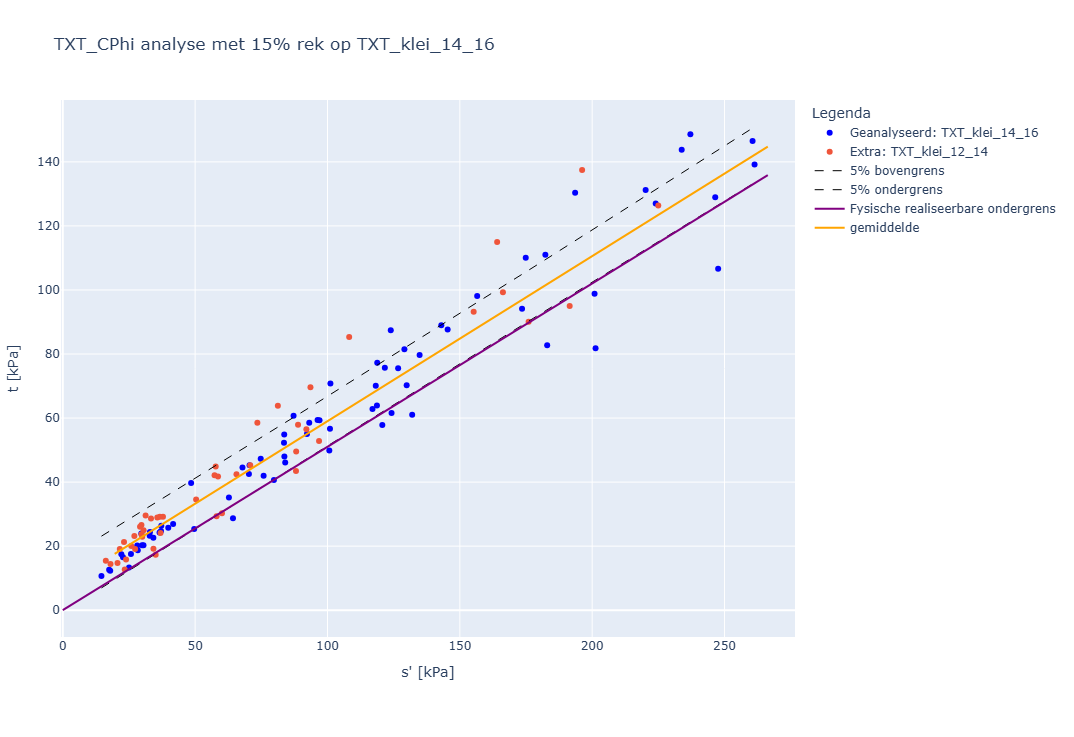

fysisch realiseerbare ondergrens gebaseerd op phi kar handmatig en cohesie kar handmatig
gemiddelde gebaseerd op helling gecorrigeerd en cohesie gem handmatig


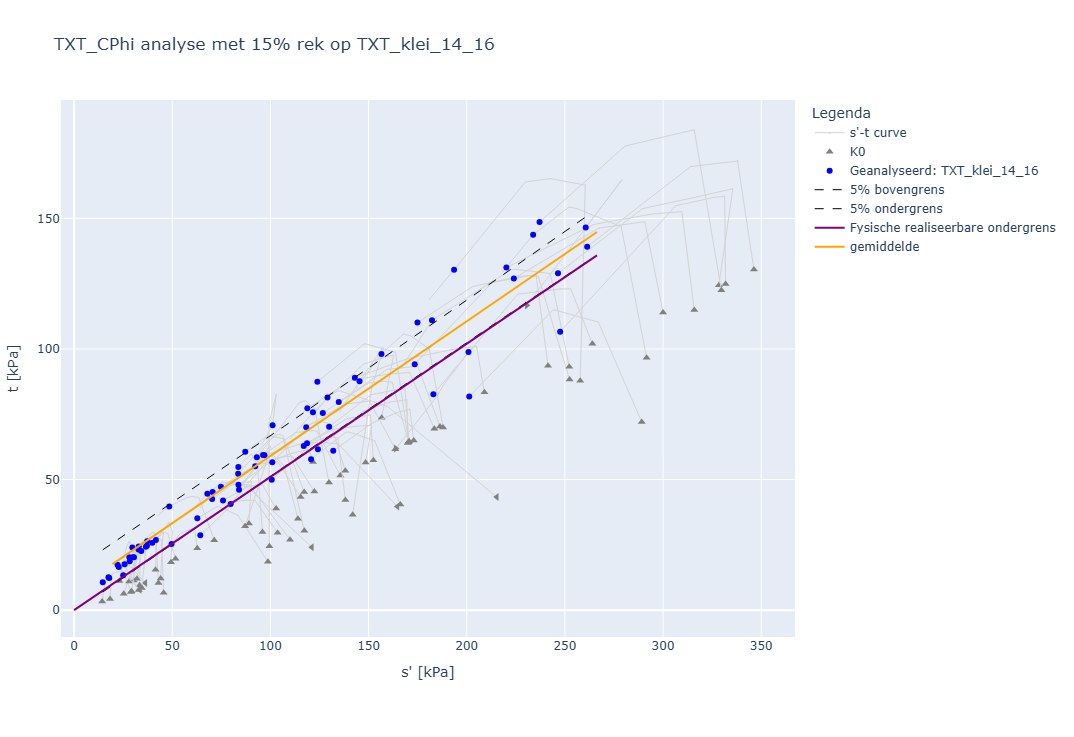

,tan phi [-],phi [graden],cohesie [kPa]
Verwachtingswaarde,0.60156,31.029452,8.752455
Karakteristieke waarde,0.592903,30.663830,0.011626
Rekenwaarde,0.592903,30.663830,0.011626
Standaarddeviatie D-stability,[-],0.223118,137.957458


In [12]:
#voer C-phi analyse uit met invoer en toon grafieken
if dropdown_type_proef.value.startswith('TXT'):
    rekpercentage = dropdown_rekpercentage_txt.value
else:
    rekpercentage = dropdown_rekpercentage_dss.value

analyse = CPhiAnalyse(dbase=dbase, investigation_groups=[dropdown_verzameling.value], effective_stress= rekpercentage, analysis_type=dropdown_type_proef.value)
analyse.apply_parameters(cohesie_gem = PV_A1_COH_GEM_handmatig[0], phi_kar = PV_A2_PHI_KAR_handmatig[0], cohesie_kar = PV_A1_COH_KAR_handmatig[0])
analyse.apply_settings(material_factor_cohesion = PV_PARTCOH[0], material_factor_tan_phi = PV_PARTPHI[0], alpha = PV_TYPEVERZAMELING[0])

#Toon resultaten figuur en tabel met cohesie en hoek van inwendige wrijving
extra_verzamelingen_tonen = list(multi_select_verzameling.value)
analyse.show_figure(plot_extra_dataset= extra_verzamelingen_tonen )
analyse.show_figure(plot_spanningspaden=True)

analyse.print_short_results()

fysisch realiseerbare ondergrens gebaseerd op eerste benadering a1 en eerste benadering a2
gemiddelde gebaseerd op helling gecorrigeerd en eerste benadering a1 gem


C:\python_cursus\PVtool2025_github\pv_tool\cphi_analysis\calc_parameters.py:202: UserWarning:

Om berekening standaarddeviatie voor D-stability te kunnen doen moet rekenwaarde van de cohesie waarde positief zijn, gevonden waarde: -2.635.Rekenwaarde cohesie wordt aangepast naar 0.01 om berekening standaarddeviatie voor D-stability te kunnen doen



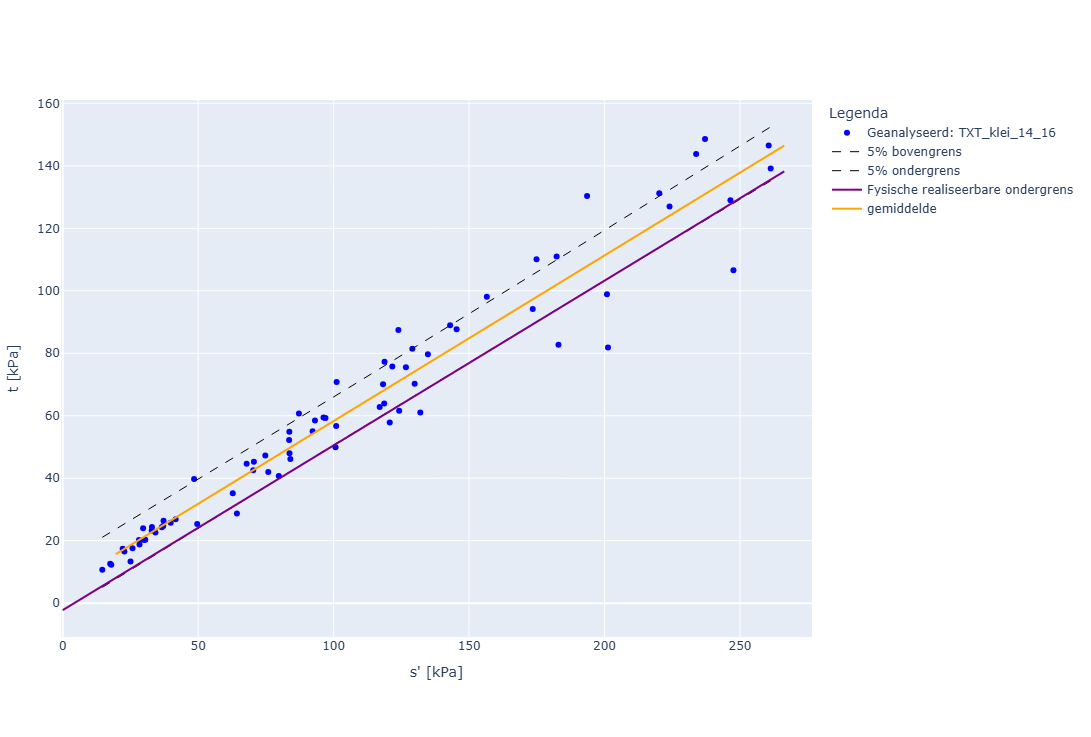

C:\python_cursus\PVtool2025_github\pv_tool\cphi_analysis\calc_parameters.py:202: UserWarning:

Om berekening standaarddeviatie voor D-stability te kunnen doen moet rekenwaarde van de cohesie waarde positief zijn, gevonden waarde: -2.635.Rekenwaarde cohesie wordt aangepast naar 0.01 om berekening standaarddeviatie voor D-stability te kunnen doen



PermissionError: [Errno 13] Permission denied: 'C:\\python_cursus\\PVtool2025_github\\resultaten/c_phi_pdf_export_TXT_klei_14_16_TXT_CPhi_15procent_rek.pdf'

In [15]:
# Resultaten opslaan naar: ##_PVtool5_0.xlsx, pdf en exporteer tussenstappen naar excel
import os

#directory om resultaten weg te schrijven
output_path1 = os.path.join(os.getcwd(), "resultaten")
os.makedirs(output_path1, exist_ok=True)

# Sla resultaten op als PDF
analyse.save_to_pdf(path=output_path1) 

# schrijf invoer en resultaten naar PV_template, tabblad resultaten c-phi.
analyse.add_results_to_dbase(path=dir2, file_name=filename_export)

# Opslaan tussenresultaten naar Excel
bestand_naam = os.path.join(output_path1, "c_phi_data_geforceerd.xlsx")
analyse.cphi_analyses_data_df.to_excel(bestand_naam, index=False)

#Plotly bestand maken 
fig_s_t = analyse.figure  # of analyse.fig als die bestaat
bestandsnaam = dropdown_verzameling.value.replace(' ', '_') + '.html'
output_path = os.path.join(output_path1, bestandsnaam)
fig_s_t.write_html(output_path)
print(f"Figuur opgeslagen als {output_path}")


In [16]:
# work in progress widget voor Shansep

import ipywidgets as widgets
from IPython.display import display, Markdown

# Vooraf berekende waarden ingeven. Deze worden straks vanuit de berekening ingevoerd.

# Kolom 2: Snijpunt y-as
SNIJPUNT_GEM_BENADERING_R2 = 9.75
SNIJPUNT_GEM_BENADERING_R3 = None
SNIJPUNT_GEM_BENADERING_R4 = None
SNIJPUNT_GEM_BENADERING_R5 = None

# Kolom 3: Schuifsterkteratio S
S_GEM_BENADERING_UIT_S_en_POP_R2 = 0.324
S_GEM_BENADERING_UIT_S_en_m_R3 = 0.324
S_GEM_BENADERING_R4 = None
S_GEM_BENADERING_UIT_S_OCR1_R5 = 0.306

# Kolom 4: Sterktetoename exponent m
m__GEM_BENADERING_R2 = None
m_GEM_BENADERING_uit_S_en_m_R3 = 0.95
m_GEM_BENADERING_R4 = None
m_GEM_BENADERING_R5 = None

# Kolom 5: POP
POP_GEM_BENADERING_UIT_snijpunt_S_en_m_R1 = 32
POP_GEM_BENADERING_UIT_snijpunt_S_en_m_R2 = POP_GEM_BENADERING_UIT_snijpunt_S_en_m_R1
POP_GEM_BENADERING_UIT_TXT_R3 = 44
POP_GEM_BENADERING_R4 = None

# Beschrijvingen (eerste kolom)
descriptions = [
    "bepaling S en POP uit triaxiaal- of DSS proeven",
    "bepaling S en m uit triaxiaal- of DSS proeven",
    "o.b.v. opgegeven POP bij triaxiaal- of DSS proeven",
    "bepaling S uit triaxiaal- of DSS proeven OCR=1"
]

# Maak een raster van 6 rijen en 5 kolommen
grid = widgets.GridspecLayout(6, 5, width='1050px')  # Breder raster

# Veldnamen (eerste rij)
grid[0, 0] = widgets.Label("Parameters", layout=widgets.Layout(width='300px'))  # Brede eerste kolom
grid[0, 1] = widgets.Label("Snijpunt y-as")
grid[0, 2] = widgets.Label("Schuifsterkteratio S")
grid[0, 3] = widgets.Label("Sterkte toename exponent m")
grid[0, 4] = widgets.Label("POP")

# Functie voor berekening van rij 6 kolom 5
def bereken_resultaat(change):
    try:
        kolom_2 = float(input_row_6_kol_2.value)
        kolom_3 = float(input_row_6_kol_3.value)
        kolom_4 = float(input_row_6_kol_4.value)
        result.value = str(kolom_2 + kolom_3 + kolom_4)
    except ValueError:
        result.value = "Invalid"

# Vul de tabel rijen 2 t/m 5 met berekende waarden
for i, (desc, y_as, S, m, pop) in enumerate(zip(
    descriptions,
    [SNIJPUNT_GEM_BENADERING_R2, SNIJPUNT_GEM_BENADERING_R3, SNIJPUNT_GEM_BENADERING_R4, SNIJPUNT_GEM_BENADERING_R5],
    [S_GEM_BENADERING_UIT_S_en_POP_R2, S_GEM_BENADERING_UIT_S_en_m_R3, S_GEM_BENADERING_R4, S_GEM_BENADERING_UIT_S_OCR1_R5],
    [m__GEM_BENADERING_R2, m_GEM_BENADERING_uit_S_en_m_R3, m_GEM_BENADERING_R4, m_GEM_BENADERING_R5],
    [POP_GEM_BENADERING_UIT_snijpunt_S_en_m_R1, POP_GEM_BENADERING_UIT_snijpunt_S_en_m_R2, POP_GEM_BENADERING_UIT_TXT_R3, POP_GEM_BENADERING_R4]
), start=1):
    grid[i, 0] = widgets.Label(desc, layout=widgets.Layout(width='350px'))  # Beschrijving (eerste kolom)
    grid[i, 1] = widgets.Label(str(y_as) if y_as is not None else "-")  # Snijpunt y-as
    grid[i, 2] = widgets.Label(str(S) if S is not None else "-")  # Schuifsterkteratio S
    grid[i, 3] = widgets.Label(str(m) if m is not None else "-")  # Sterkte toename exponent m
    grid[i, 4] = widgets.Label(str(pop) if pop is not None else "-")  # POP

# Toevoegen van invoervelden in rij 6
grid[5, 0] = widgets.Label("Handmatige invoer", layout=widgets.Layout(width='350px'))
input_row_6_kol_2 = widgets.FloatText(value=0.0, layout=widgets.Layout(width='180px'))
input_row_6_kol_3 = widgets.FloatText(value=0.0, layout=widgets.Layout(width='180px'))
input_row_6_kol_4 = widgets.FloatText(value=0.0, layout=widgets.Layout(width='180px'))
result = widgets.Label("")

# Koppel invoervelden aan de tabel
grid[5, 1] = input_row_6_kol_2
grid[5, 2] = input_row_6_kol_3
grid[5, 3] = input_row_6_kol_4

# Bereken resultaat in kolom 5
input_row_6_kol_2.observe(bereken_resultaat, names="value")
input_row_6_kol_3.observe(bereken_resultaat, names="value")
input_row_6_kol_4.observe(bereken_resultaat, names="value")
grid[5, 4] = result

# Toon de tabelwidget
display(Markdown("**Opgeven gemiddelde waarden (fit):**"))
display(grid)

**Opgeven gemiddelde waarden (fit):**

GridspecLayout(children=(Label(value='Parameters', layout=Layout(grid_area='widget001', width='300px')), Label…

In [ ]:
# Laden van widgets voor keuzes afleiden gedraineerde parameters
import ipywidgets as widgets
from IPython.display import display, Markdown

# Dataframe met proefdata
dbase_df = dbase.dbase_df

# Filter op triaxiaal en DSS en haal unieke PV_NAAM per type op + optie 'geen' aan lijst toegevoegd
PV_txt_lijst = ['geen'] + dbase_df.loc[dbase_df['ALG__TRIAXIAAL'], 'PV_NAAM'].dropna().unique().tolist()
PV_dss_lijst = ['geen'] + dbase_df.loc[dbase_df['ALG__DSS'], 'PV_NAAM'].dropna().unique().tolist()

#### Widgets 
# # Dropdown widget voor rek%
dropdown_rekpercentage = widgets.Dropdown(options=['2% rek', '5% rek', '15% rek', 'eindsterkte', 'pieksterkte'], value='eindsterkte', layout=widgets.Layout(width='400px'))

# Dropdown widget met lijst onderscheiden proevenverzamelingen
dropdown_verzameling_txt = widgets.Dropdown(options=PV_txt_lijst, value=PV_txt_lijst[0] if PV_txt_lijst else None, layout=widgets.Layout(width='400px'))

# Dropdown widget met multiselect om verschillende verzamelingen te tonen naast de gekozen verzameling voor de statistische analyse
multi_select_verzameling = widgets.SelectMultiple(options=PV_txt_lijst, value=[PV_txt_lijst[0]] if PV_txt_lijst else [], layout=widgets.Layout(width='400px', height='150px'))

#### WIDGETS TONEN
display(Markdown("**Kies verzameling voor statistische analyse:**"))
display(dropdown_verzameling_txt)

display(Markdown("**Kies rekpercentage s'en t:**"))
display(dropdown_rekpercentage)

display(Markdown("**Kies één of meerdere verzamelingen om naast de gekozen verzameling voor de statistische analyse te tonen:**"))
display(multi_select_verzameling)

print()